In [1]:
import os
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print('TensorFlow:', tf.__version__)

# Reproducibility
SEED = 42
keras.utils.set_random_seed(SEED)

autotune = tf.data.AUTOTUNE

TensorFlow: 2.20.0


In [2]:
import ctypes

train_dir = "C:/Users/nguye/OneDrive/Máy tính/University courses/Sem1_2026/COS30082/Week4/seg_train"
test_dir = "C:/Users/nguye/OneDrive/Máy tính/University courses/Sem1_2026/COS30082/Week4/seg_test"

def windows_short_path(p: Path) -> str:
    s = str(p)
    if os.name != 'nt':
        return s
    GetShortPathNameW = ctypes.windll.kernel32.GetShortPathNameW
    GetShortPathNameW.argtypes = [ctypes.c_wchar_p, ctypes.c_wchar_p, ctypes.c_uint]
    GetShortPathNameW.restype = ctypes.c_uint
    buf = ctypes.create_unicode_buffer(4096)
    n = GetShortPathNameW(s, buf, 4096)
    return buf.value if n != 0 else s

train_dir_safe = windows_short_path(train_dir)
test_dir_safe = windows_short_path(test_dir)

print('train_dir_safe: ', train_dir_safe)
print('test_dir_safe:  ', test_dir_safe)

train_dir_safe:  C:/Users/nguye/OneDrive/MYTNH~1/UNIVER~1/SEM1_2~3/COS30082/Week4/SEG_TR~1
test_dir_safe:   C:/Users/nguye/OneDrive/MYTNH~1/UNIVER~1/SEM1_2~3/COS30082/Week4/seg_test


In [3]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

# Prefer relative paths when available; otherwise use safe paths
train_ds = keras.utils.image_dataset_from_directory(
    train_dir_safe,
    labels='inferred',
    label_mode='int',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    validation_split=0.2,
    subset='training',
)

val_ds = keras.utils.image_dataset_from_directory(
    train_dir_safe,
    labels='inferred',
    label_mode='int',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    validation_split=0.2,
    subset='validation',
)

test_ds = keras.utils.image_dataset_from_directory(
    test_dir_safe,
    labels='inferred',
    label_mode='int',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

class_names = train_ds.class_names
num_classes = len(class_names)
print('Classes:', class_names)

# Normalize to [0,1]
normalizer = layers.Rescaling(1.0 / 255)

def normalize_batch(x, y):
    return normalizer(x), y

train_ds_n = train_ds.map(normalize_batch, num_parallel_calls=autotune)
val_ds_n = val_ds.map(normalize_batch, num_parallel_calls=autotune)
test_ds_n = test_ds.map(normalize_batch, num_parallel_calls=autotune)

# Performance
train_ds_n = train_ds_n.cache().prefetch(autotune)
val_ds_n = val_ds_n.cache().prefetch(autotune)
test_ds_n = test_ds_n.cache().prefetch(autotune)

Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [4]:
def count_samples(ds: tf.data.Dataset) -> int:
    total = 0
    for _, y in ds:
        total += y.shape[0]
    return int(total)

n_train = count_samples(train_ds)
n_val = count_samples(val_ds)
n_test = count_samples(test_ds)

print('Number of training samples:  ', n_train)
print('Number of validation samples:', n_val)
print('Number of test samples:      ', n_test)
print('Number of classes:           ', num_classes)

Number of training samples:   11228
Number of validation samples: 2806
Number of test samples:       3000
Number of classes:            6


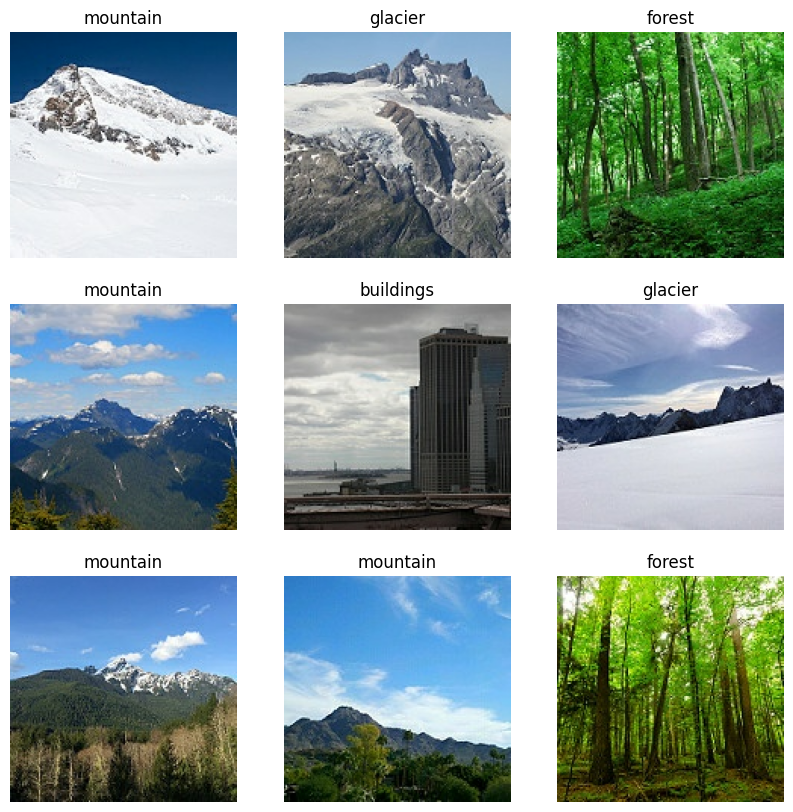

In [5]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[int(labels[i])])
        plt.axis('off')
plt.show()

In [6]:
def compile_and_train(model: keras.Model, train_ds, val_ds, *, epochs: int, callbacks=None):
    model.compile(
        optimizer=keras.optimizers.Adam(),
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=['accuracy'],
    )
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=callbacks or [],
        verbose=1,
    )
    return history

# Keep results/models if you re-run this cell
results = globals().get('results', {})
models = globals().get('models', {})
print('Currently have results for:', sorted(results.keys()))

Currently have results for: []


In [9]:
baseline_model = keras.Sequential([
    layers.Input(shape=(*IMG_SIZE, 3)),
    layers.Conv2D(16, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax'),
], name='baseline_cnn')

baseline_model.summary()

_ = compile_and_train(baseline_model, train_ds_n, val_ds_n, epochs=10)

test_loss, test_acc = baseline_model.evaluate(test_ds_n, verbose=0)
results['Task2_baseline'] = {'test_accuracy': float(test_acc), 'test_loss': float(test_loss)}
models['Task2_baseline'] = baseline_model
print('Baseline test accuracy:', test_acc)

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 148, 148, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 74, 74, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 87616)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │     5,607,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,608,326 (21.39 MB)

 Trainable params: 5,608,326 (21.39 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 22s 60ms/step - accuracy: 0.5695 - loss: 1.2506 - val_accuracy: 0.6971 - val_loss: 0.8382
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.7821 - loss: 0.6350 - val_accuracy: 0.6768 - val_loss: 0.8842
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.8589 - loss: 0.4337 - val_accuracy: 0.7434 - val_loss: 0.7330
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step - accuracy: 0.9131 - loss: 0.2853 - val_accuracy: 0.6768 - val_loss: 1.0255
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step - accuracy: 0.9377 - loss: 0.2100 - val_accuracy: 0.6978 - val_loss: 0.9964
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 21s 61ms/step - accuracy: 0.9615 - loss: 0.1437 - val_accuracy: 0.7017 - val_loss: 1.1712
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step - accuracy: 0.9813 - loss: 0.0808 - val_accuracy: 0.7120 - val_loss: 1.1621
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 21s 61ms/step - accuracy: 0.9918 - loss: 0.0505 - 

In [10]:
modified_model = keras.Sequential([
    layers.Input(shape=(*IMG_SIZE, 3)),

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax'),
], name='modified_cnn')

modified_model.summary()

_ = compile_and_train(modified_model, train_ds_n, val_ds_n, epochs=10)

test_loss, test_acc = modified_model.evaluate(test_ds_n, verbose=0)
results['Task3_modified'] = {'test_accuracy': float(test_acc), 'test_loss': float(test_loss)}
models['Task3_modified'] = modified_model
print('Modified CNN test accuracy:', test_acc)

Model: "modified_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 75, 75, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │     1,327,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,356,198 (5.17 MB)

 Trainable params: 1,356,198 (5.17 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 37s 105ms/step - accuracy: 0.6114 - loss: 1.0019 - val_accuracy: 0.6892 - val_loss: 0.7677
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 38s 107ms/step - accuracy: 0.7496 - loss: 0.6810 - val_accuracy: 0.7662 - val_loss: 0.6225
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 34s 96ms/step - accuracy: 0.8191 - loss: 0.5048 - val_accuracy: 0.7655 - val_loss: 0.6563
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 35s 99ms/step - accuracy: 0.8631 - loss: 0.3926 - val_accuracy: 0.7933 - val_loss: 0.6189
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 35s 99ms/step - accuracy: 0.8968 - loss: 0.2938 - val_accuracy: 0.7837 - val_loss: 0.6999
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 34s 97ms/step - accuracy: 0.9257 - loss: 0.2144 - val_accuracy: 0.7840 - val_loss: 0.7884
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 35s 100ms/step - accuracy: 0.9507 - loss: 0.1502 - val_accuracy: 0.7676 - val_loss: 0.9516
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 35s 100ms/step - accuracy: 0.9590 - loss: 0.120

In [11]:
augment_layers = keras.Sequential([
    layers.RandomFlip('horizontal', seed=SEED),
    layers.RandomRotation(0.1, seed=SEED),
    layers.RandomZoom(0.1, seed=SEED),
], name='augment_layers')

def augment_batch(x, y):
    x = augment_layers(x, training=True)
    # brightness: delta in [-0.1, +0.1]
    x = tf.image.random_brightness(x, max_delta=0.1)
    x = tf.clip_by_value(x, 0.0, 1.0)
    return x, y

train_ds_aug = train_ds_n.map(augment_batch, num_parallel_calls=autotune).prefetch(autotune)

augmented_model = keras.Sequential([
    layers.Input(shape=(*IMG_SIZE, 3)),

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax'),
], name='cnn_with_augmentation')

augmented_model.summary()

_ = compile_and_train(augmented_model, train_ds_aug, val_ds_n, epochs=10)

test_loss, test_acc = augmented_model.evaluate(test_ds_n, verbose=0)
results['Task4_augmentation'] = {'test_accuracy': float(test_acc), 'test_loss': float(test_loss)}
models['Task4_augmentation'] = augmented_model
print('Augmentation test accuracy:', test_acc)

Model: "cnn_with_augmentation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 75, 75, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │     1,327,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,356,198 (5.17 MB)

 Trainable params: 1,356,198 (5.17 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 44s 123ms/step - accuracy: 0.5396 - loss: 1.1699 - val_accuracy: 0.6885 - val_loss: 0.8401
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 40s 114ms/step - accuracy: 0.6681 - loss: 0.8903 - val_accuracy: 0.6864 - val_loss: 0.8491
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 41s 116ms/step - accuracy: 0.7058 - loss: 0.7959 - val_accuracy: 0.7138 - val_loss: 0.7797
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 39s 110ms/step - accuracy: 0.7404 - loss: 0.7107 - val_accuracy: 0.7103 - val_loss: 0.7782
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 38s 106ms/step - accuracy: 0.7550 - loss: 0.6628 - val_accuracy: 0.7562 - val_loss: 0.6621
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 40s 113ms/step - accuracy: 0.7664 - loss: 0.6281 - val_accuracy: 0.7684 - val_loss: 0.6449
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 40s 114ms/step - accuracy: 0.7890 - loss: 0.5876 - val_accuracy: 0.7919 - val_loss: 0.5869
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 39s 111ms/step - accuracy: 0.7929 - loss: 0

In [13]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True,
)

regularized_model = keras.Sequential([
    layers.Input(shape=(*IMG_SIZE, 3)),

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax'),
], name='cnn_with_regularization')

regularized_model.summary()

_ = compile_and_train(regularized_model, train_ds_n, val_ds_n, epochs=15, callbacks=[early_stop])

test_loss, test_acc = regularized_model.evaluate(test_ds_n, verbose=0)
results['Task5_regularization'] = {'test_accuracy': float(test_acc), 'test_loss': float(test_loss)}
models['Task5_regularization'] = regularized_model
print('Regularization test accuracy:', test_acc)

Model: "cnn_with_regularization"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 75, 75, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │     1,327,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,356,198 (5.17 MB)

 Trainable params: 1,356,198 (5.17 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 37s 101ms/step - accuracy: 0.5647 - loss: 1.1073 - val_accuracy: 0.6871 - val_loss: 0.8187
Epoch 2/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 36s 102ms/step - accuracy: 0.6995 - loss: 0.8109 - val_accuracy: 0.7669 - val_loss: 0.6457
Epoch 3/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 34s 97ms/step - accuracy: 0.7589 - loss: 0.6524 - val_accuracy: 0.7801 - val_loss: 0.5933
Epoch 4/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 33s 95ms/step - accuracy: 0.7963 - loss: 0.5640 - val_accuracy: 0.7855 - val_loss: 0.5940
Epoch 5/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 33s 95ms/step - accuracy: 0.8351 - loss: 0.4665 - val_accuracy: 0.8086 - val_loss: 0.5826
Epoch 6/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 33s 94ms/step - accuracy: 0.8406 - loss: 0.4366 - val_accuracy: 0.7926 - val_loss: 0.6372
Epoch 7/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 33s 95ms/step - accuracy: 0.8643 - loss: 0.3649 - val_accuracy: 0.8104 - val_loss: 0.6237
Epoch 8/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 34s 95ms/step - accuracy: 0.8817 - loss: 0.3310 

In [24]:
# Comparison table
rows = []
for k, v in results.items():
    rows.append((k, v['test_accuracy'], v['test_loss']))
rows = sorted(rows, key=lambda t: t[0])

print('Test set results:')
for name, acc, loss in rows:
    print(f"- {name:18s}: acc={acc:.4f}, loss={loss:.4f}")

# Write a short report next to this notebook
report_path = Path.cwd() / 'lab04_report.md'

def model_summary_text(m: keras.Model) -> str:
    lines = []
    m.summary(print_fn=lambda s: lines.append(s))
    return '\n'.join(lines)

report = []
report.append('* CNN Intel Image Classification Report\n')
report.append('** Dataset\n')
report.append(f"- Classes (n={num_classes}): {', '.join(class_names)}\n")
report.append(f"- Train samples: {n_train}\n- Validation samples: {n_val}\n- Test samples: {n_test}\n")

report.append('** Training settings\n')
report.append('- Image size: 150x150\n- Normalization: Rescaling(1/255) to [0,1]\n- Loss: SparseCategoricalCrossentropy\n- Optimizer: Adam\n- Metric: accuracy\n')

report.append('** Data augmentation (Task 4)\n')
report.append('- RandomFlip(horizontal)\n- RandomRotation(0.1)\n- RandomZoom(0.1)\n- Random brightness (tf.image.random_brightness, max_delta=0.1)\n')

report.append('** Regularization (Task 5)\n')
report.append('- Dropout(0.5) after Flatten\n- Dropout(0.3) after Dense(64)\n- EarlyStopping(monitor=val_accuracy, patience=3, restore_best_weights=True)\n')

report.append('** Model architectures\n')
for key in ['Task2_baseline', 'Task3_modified', 'Task4_augmentation', 'Task5_regularization']:
    if key in models:
        report.append(f"*** {key}\n")
        report.append(model_summary_text(models[key]))

report.append('** Test accuracy comparison\n')
report.append('Task | Test accuracy | Test loss \n')
for name, acc, loss in rows:
    report.append(f"{name} | {acc:.4f} | {loss:.4f} \n")
print('The report is saved in:', report_path)

Test set results:
- Task2_baseline    : acc=0.7003, loss=1.5280
- Task3_modified    : acc=0.7750, loss=1.2726
- Task4_augmentation: acc=0.7877, loss=0.6234
- Task5_regularization: acc=0.8250, loss=0.6734


The report is saved in: c:\Users\nguye\OneDrive\Máy tính\University courses\Sem1_2026\COS30082\Week4\lab04_report.md
